<a href="https://colab.research.google.com/github/k-krishna-teja/01-TMDB-Dataset-Analysis-project/blob/main/Final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Quantum device (2 qubits)
dev = qml.device("default.qubit", wires=2)

In [78]:
# Normal data
normal_data = np.random.normal(loc=0, scale=0.8, size=(100, 2))

# Anomalies (overlapping)
anomalies = np.random.normal(loc=1.5, scale=1.0, size=(20, 2))

# Add noise
normal_data += np.random.normal(0, 0.2, normal_data.shape)
anomalies += np.random.normal(0, 0.2, anomalies.shape)

# Test split
test_normal = normal_data[:20]
test_anomaly = anomalies

test_data = np.vstack([test_normal, test_anomaly])

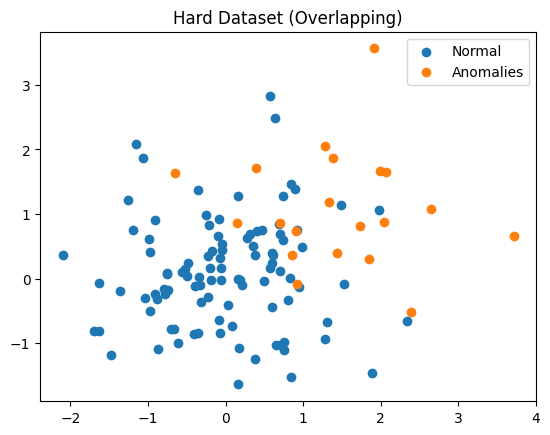

In [79]:
plt.scatter(normal_data[:,0], normal_data[:,1], label="Normal")
plt.scatter(anomalies[:,0], anomalies[:,1], label="Anomalies")
plt.legend()
plt.title("Hard Dataset (Overlapping)")
plt.show()

In [80]:
@qml.qnode(dev)
def circuit(x, weights):
    # --- Encoding ---
    qml.RY(x[0], wires=0)
    qml.RY(x[1], wires=1)

    # --- Layer 1 ---
    qml.RY(weights[0], wires=0)
    qml.RY(weights[1], wires=1)
    qml.CNOT(wires=[0, 1])

    # --- Layer 2 ---
    qml.RY(weights[2], wires=0)
    qml.RY(weights[3], wires=1)
    qml.CNOT(wires=[1, 0])

    # --- Layer 3 (NEW) ---
    qml.RY(weights[4], wires=0)
    qml.RY(weights[5], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[1, 0])

    return qml.expval(qml.PauliZ(0))

In [81]:
def loss(weights):
    outputs = np.array([circuit(x, weights) for x in normal_data])
    mean = np.mean(outputs)
    return np.mean((outputs - mean)**2)

In [82]:
# IMPORTANT: use pennylane numpy
weights = np.array(np.random.randn(6), requires_grad=True)

opt = qml.GradientDescentOptimizer(stepsize=0.1)

epochs = 60

In [83]:
for i in range(epochs):
    weights = opt.step(loss, weights)

    if i % 10 == 0:
        print(f"Epoch {i}, Loss: {loss(weights):.6f}")

Epoch 0, Loss: 0.148017
Epoch 10, Loss: 0.139266
Epoch 20, Loss: 0.134073
Epoch 30, Loss: 0.130690
Epoch 40, Loss: 0.128307
Epoch 50, Loss: 0.126533


In [84]:
train_outputs = np.array([circuit(x, weights) for x in normal_data])
mean_output = np.mean(train_outputs)

In [85]:
def anomaly_score(x):
    output = circuit(x, weights)
    return abs(output - mean_output)

In [86]:
threshold = np.percentile(
    [anomaly_score(x) for x in normal_data], 95
)
predictions = ["Anomaly" if s > threshold else "Normal" for s in scores]

In [87]:
scores = [anomaly_score(x) for x in test_data]

pred_labels = [1 if s > threshold else 0 for s in scores]

true_labels = [0]*len(test_normal) + [1]*len(test_anomaly)

In [88]:
from sklearn.metrics import confusion_matrix

accuracy = np.mean(np.array(true_labels) == np.array(pred_labels))
print("Accuracy:", accuracy)

print("Confusion Matrix:")
print(confusion_matrix(true_labels, pred_labels))

Accuracy: 0.7
Confusion Matrix:
[[19  1]
 [11  9]]


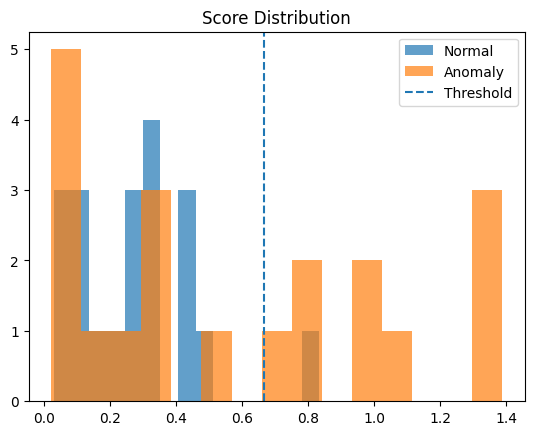

In [89]:
normal_scores = [anomaly_score(x) for x in test_normal]
anomaly_scores = [anomaly_score(x) for x in test_anomaly]

plt.hist(normal_scores, bins=15, alpha=0.7, label="Normal")
plt.hist(anomaly_scores, bins=15, alpha=0.7, label="Anomaly")

plt.axvline(threshold, linestyle='--', label="Threshold")

plt.legend()
plt.title("Score Distribution")
plt.show()

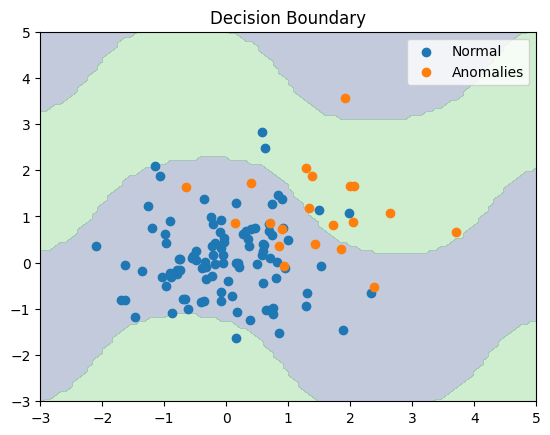

In [90]:
x_min, x_max = -3, 5
y_min, y_max = -3, 5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_scores = np.array([anomaly_score(p) for p in grid_points])
Z = grid_scores.reshape(xx.shape)

plt.contourf(xx, yy, Z > threshold, alpha=0.3)

plt.scatter(normal_data[:,0], normal_data[:,1], label="Normal")
plt.scatter(anomalies[:,0], anomalies[:,1], label="Anomalies")

plt.legend()
plt.title("Decision Boundary")
plt.show()

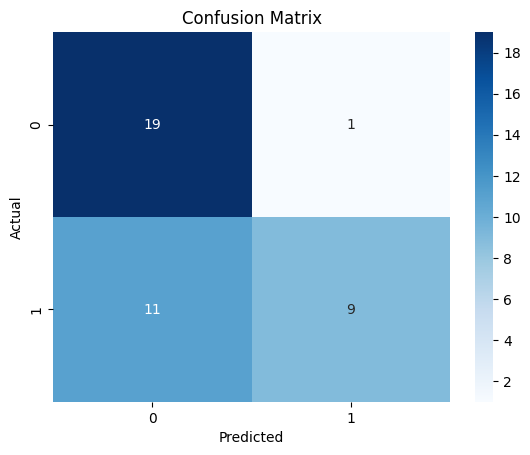

In [91]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, pred_labels)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()